# Exploração dos Dados — Sistema de Recomendação de Filmes

Análise exploratória do dataset MovieLens para entender a estrutura dos dados antes de construir o modelo.

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Carregamento dos dados

In [143]:
ratings = pd.read_csv("../data/ratings.csv")
movies  = pd.read_csv("../data/movies.csv")

print(f"Ratings: {ratings.shape[0]:,} linhas × {ratings.shape[1]} colunas")
print(f"Movies:  {movies.shape[0]:,} linhas × {movies.shape[1]} colunas")

Ratings: 25,000,095 linhas × 4 colunas
Movies:  62,423 linhas × 3 colunas


In [144]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [145]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 2. Visão geral e qualidade dos dados

In [146]:
print("=== RATINGS ===")
print(ratings.info())
print("\nValores nulos:\n", ratings.isnull().sum())

print("\n=== MOVIES ===")
print(movies.info())
print("\nValores nulos:\n", movies.isnull().sum())

=== RATINGS ===
<class 'pandas.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB
None

Valores nulos:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

=== MOVIES ===
<class 'pandas.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  62423 non-null  int64
 1   title    62423 non-null  str  
 2   genres   62423 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.4 MB
None

Valores nulos:
 movieId    0
title      0
genres     0
dtype: int64


In [147]:
n_usuarios = ratings["userId"].nunique()
n_filmes   = ratings["movieId"].nunique()
n_avaliacoes = len(ratings)
sparsidade = 1 - (n_avaliacoes / (n_usuarios * n_filmes))

print(f"Usuários únicos : {n_usuarios:,}")
print(f"Filmes únicos   : {n_filmes:,}")
print(f"Avaliações      : {n_avaliacoes:,}")
print(f"Esparsidade     : {sparsidade:.2%}")

Usuários únicos : 162,541
Filmes únicos   : 59,047
Avaliações      : 25,000,095
Esparsidade     : 99.74%


## 3. Distribuição das avaliações

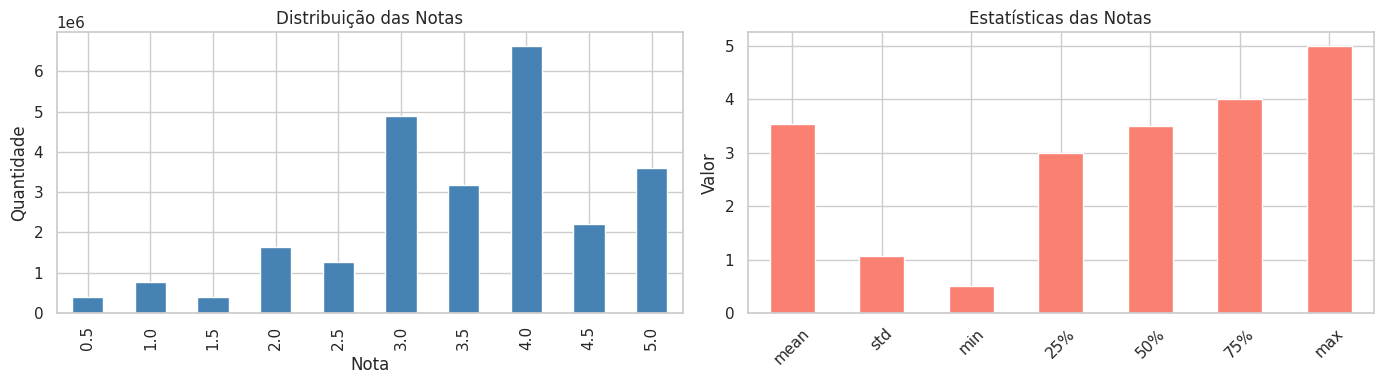

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribuição das notas
ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Distribuição das Notas")
axes[0].set_xlabel("Nota")
axes[0].set_ylabel("Quantidade")

# Estatísticas (sem count — escala incompatível com as demais)
stats = ratings["rating"].describe().drop("count")
stats.plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Estatísticas das Notas")
axes[1].set_ylabel("Valor")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 4. Filmes mais avaliados e mais bem avaliados

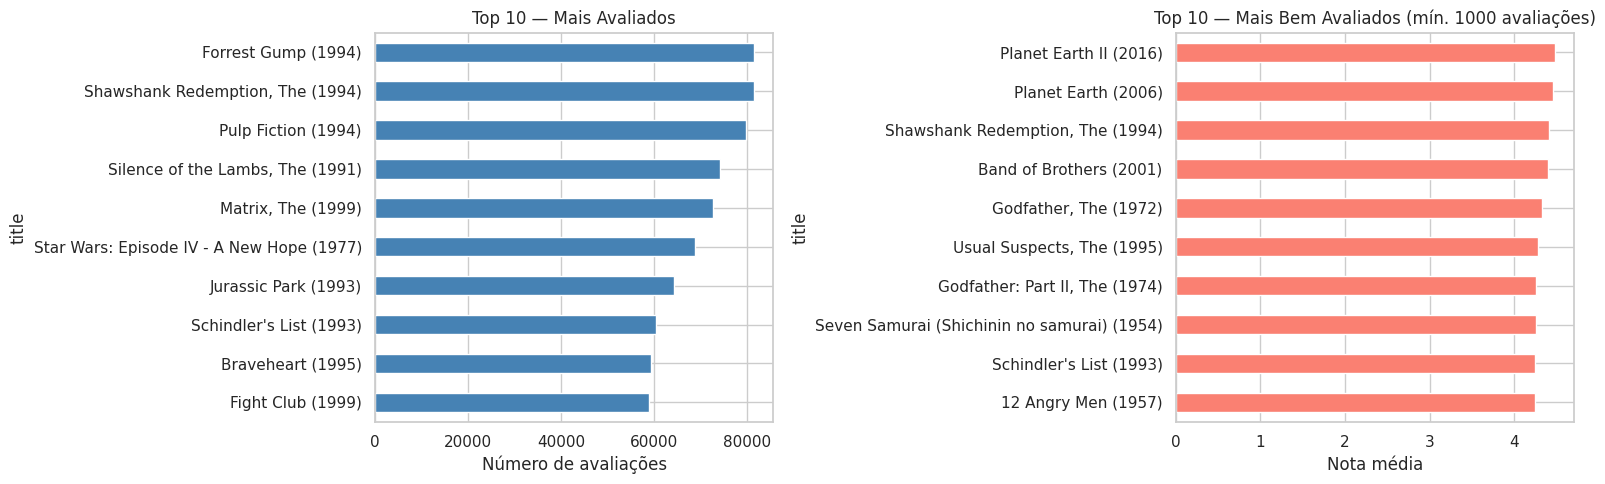

In [149]:
df = ratings.merge(movies, on="movieId")

# Top 10 mais avaliados
mais_avaliados = (
    df.groupby("title")["rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

# Top 10 mais bem avaliados (mínimo 1000 avaliações)
mais_bem_avaliados = (
    df.groupby("title")["rating"]
    .agg(["mean", "count"])
    .query("count >= 1000")
    .sort_values("mean", ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mais_avaliados.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 — Mais Avaliados")
axes[0].set_xlabel("Número de avaliações")
axes[0].invert_yaxis()

mais_bem_avaliados["mean"].plot(kind="barh", ax=axes[1], color="salmon")
axes[1].set_title("Top 10 — Mais Bem Avaliados (mín. 1000 avaliações)")
axes[1].set_xlabel("Nota média")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Distribuição dos gêneros

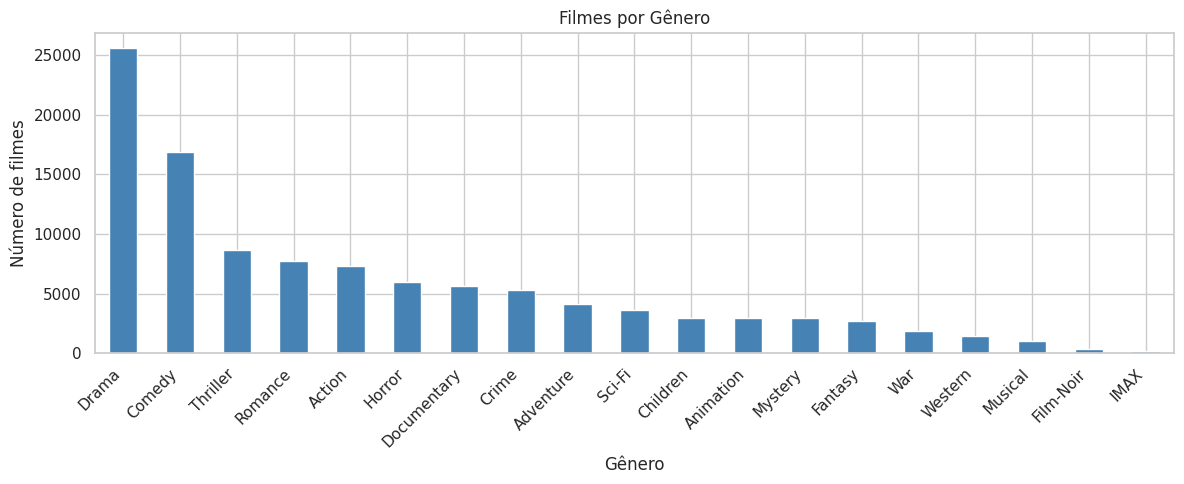

In [150]:
generos = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
    .drop("(no genres listed)", errors="ignore")
)

plt.figure(figsize=(12, 5))
generos.plot(kind="bar", color="steelblue")
plt.title("Filmes por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Número de filmes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Conclusões da Exploração

Registre aqui as principais observações encontradas nos dados antes de passar para a construção do modelo.

### Principais observações

**Volume e estrutura**
- 25 milhões de avaliações de 162 mil usuários sobre 59 mil filmes — dataset grande o suficiente para modelos robustos.
- Nenhum valor nulo em nenhuma coluna: dados limpos, sem necessidade de imputação.

**Esparsidade — o desafio central**
- 99,74% de esparsidade: cada usuário avaliou, em média, menos de 0,3% dos filmes disponíveis.
- Métodos baseados em similaridade direta (user-user, item-item) podem ser instáveis para usuários com poucas avaliações.

**Distribuição das notas**
- As notas são em incrementos de 0,5 (escala de 0,5 a 5,0).
- Usuários tendem a dar notas acima da média — viés de positividade comum em avaliações voluntárias.

**Catálogo de filmes**
- 62 mil filmes no catálogo, mas apenas 59 mil foram avaliados: ~3 mil filmes sem nenhuma avaliação (problema de *cold start* para itens).
- Drama e Comedy dominam o catálogo, o que pode introduzir viés nos top-N recomendados.

**Implicações para o modelo**

| Observação | Implicação |
|---|---|
| Alta esparsidade | Fatoração de matrizes (SVD, ALS) é mais adequada que CF baseado em memória |
| Escala de 0,5 | Tratar como regressão, não classificação binária |
| Cold start de itens | Filtrar filmes sem avaliações do conjunto de treino |
| Dataset grande | Usar bibliotecas eficientes (Surprise, implicit, LightFM) ou amostrar para prototipagem |